## 1. Import Libraries & GPU Configuration

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# GPU libraries (RAPIDS)
import cudf
import cupy as cp
import cuml
from cuml.preprocessing import StandardScaler as cuStandardScaler

# ML libraries
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Data processing (CPU fallback)
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
from config.gpu_config import (
    PARQUET_FEATURES_DIR,
    MODELS_DIR,
    GPU_DEVICE_ID,
    GPU_MEMORY_LIMIT_GB
)

# Utilities
import joblib
import gc
import time
import warnings
warnings.filterwarnings('ignore')

# Set GPU device
cp.cuda.Device(GPU_DEVICE_ID).use()

print("✓ GPU Libraries imported")
print(f"  cuDF version: {cudf.__version__}")
print(f"  cuML version: {cuml.__version__}")
print(f"  XGBoost version: {xgb.__version__}")
print(f"  GPU Device: {GPU_DEVICE_ID}")
print(f"  Memory Limit: {GPU_MEMORY_LIMIT_GB} GB")

✓ GPU Libraries imported
  cuDF version: 25.10.00
  cuML version: 25.10.00
  XGBoost version: 3.1.2
  GPU Device: 0
  Memory Limit: 60 GB


### GPU Memory Management Utilities

In [2]:
def clear_gpu_memory():
    """Clear GPU memory pools."""
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
    print("✓ GPU memory cleared")

def get_gpu_memory_usage():
    """Get current GPU memory usage."""
    mempool = cp.get_default_memory_pool()
    used = mempool.used_bytes() / 1e9
    total = mempool.total_bytes() / 1e9
    print(f"GPU Memory: {used:.2f} GB used / {total:.2f} GB allocated")
    return used, total

# Initial cleanup
clear_gpu_memory()
get_gpu_memory_usage()

✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 2. Load Feature Data (GPU)

Load engineered features from Stage 1 (03_feature_engineering.ipynb) directly into GPU memory.

In [3]:
print("LOADING FEATURE DATA (GPU)")
print("="*70)

# Select product
SELECTED_PRODUCT = "BTC-USD"
print(f"Product: {SELECTED_PRODUCT}")

# Find feature files
features_path = Path(PARQUET_FEATURES_DIR)
feature_files = sorted(list(features_path.glob(f"date=*/product_id={SELECTED_PRODUCT}/features.parquet")))

print(f"\nFound {len(feature_files)} feature files")

if len(feature_files) == 0:
    raise FileNotFoundError(f"No features found for {SELECTED_PRODUCT}. Run 03_feature_engineering.ipynb first.")

# Load files in batches to avoid OOM
BATCH_SIZE = 4  # Process 4 days at a time
all_batches = []

for i in range(0, len(feature_files), BATCH_SIZE):
    batch_files = feature_files[i:i+BATCH_SIZE]
    print(f"\nBatch {i//BATCH_SIZE + 1}: Processing {len(batch_files)} files")
    
    dfs = []
    for f in batch_files:
        gdf = cudf.read_parquet(f)
        # Extract date from path
        parts = str(f).replace('\\', '/').split('/')
        date = [p for p in parts if 'date=' in p][0].split('=')[1]
        gdf['date'] = date
        gdf['product_id'] = SELECTED_PRODUCT
        dfs.append(gdf)
        print(f"  Loaded: {date} ({len(gdf):,} rows)")
    
    # Concatenate batch
    batch_df = cudf.concat(dfs, ignore_index=True)
    all_batches.append(batch_df)
    
    # Memory check
    get_gpu_memory_usage()
    
    # Clear intermediate data
    del dfs
    clear_gpu_memory()

# Final concatenation
print("\nConcatenating all batches...")
df = cudf.concat(all_batches, ignore_index=True)

print(f"\n✓ Loaded {len(df):,} total rows")
print(f"  Columns: {len(df.columns)}")
print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
get_gpu_memory_usage()

# Clean up
del all_batches
clear_gpu_memory()

LOADING FEATURE DATA (GPU)
Product: BTC-USD

Found 16 feature files

Batch 1: Processing 4 files
  Loaded: 2025-11-08 (8,594 rows)
  Loaded: 2025-11-09 (8,633 rows)
  Loaded: 2025-11-10 (8,592 rows)
  Loaded: 2025-11-11 (8,272 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Batch 2: Processing 4 files
  Loaded: 2025-11-12 (8,582 rows)
  Loaded: 2025-11-13 (8,589 rows)
  Loaded: 2025-11-14 (8,546 rows)
  Loaded: 2025-11-15 (8,627 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Batch 3: Processing 4 files
  Loaded: 2025-11-16 (8,626 rows)
  Loaded: 2025-11-17 (8,627 rows)
  Loaded: 2025-11-18 (8,609 rows)
  Loaded: 2025-11-19 (8,557 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Batch 4: Processing 4 files
  Loaded: 2025-11-20 (8,586 rows)
  Loaded: 2025-11-21 (8,617 rows)
  Loaded: 2025-11-22 (8,628 rows)
  Loaded: 2025-11-23 (8,625 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Concate

## 3. Temporal Train/Test Split (Maintains Time Continuity)

**Critical**: Split by time, NOT random. Train on earlier days, test on later days.

In [4]:
print("TEMPORAL TRAIN/TEST SPLIT")
print("="*70)

# First, check what columns we have
print(f"Available columns: {df.columns.tolist()[:10]}...")  # Show first 10
print(f"Total columns: {len(df.columns)}")

# Sort by date and timestamp (ensure temporal order)
# Column name is 'timestamp' not 'timestamp_exchange'
if 'timestamp' in df.columns:
    df = df.sort_values(['date', 'timestamp'])
elif 'time' in df.columns:
    df = df.sort_values(['date', 'time'])
else:
    # Just sort by date if no timestamp column
    df = df.sort_values('date')
    print("⚠️  No timestamp column found, sorting by date only")

# Get unique dates
dates = df['date'].unique().to_pandas().sort_values()
n_dates = len(dates)
split_idx = int(n_dates * 0.75)

train_dates = dates[:split_idx]
test_dates = dates[split_idx:]

print(f"\nTotal dates: {n_dates}")
print(f"Train dates: {len(train_dates)} ({train_dates.min()} to {train_dates.max()})")
print(f"Test dates: {len(test_dates)} ({test_dates.min()} to {test_dates.max()})")

# Split data (maintains temporal order within each split)
train_mask = df['date'].isin(train_dates)
test_mask = df['date'].isin(test_dates)

df_train = df[train_mask]
df_test = df[test_mask]

print(f"\nTrain: {len(df_train):,} rows ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test:  {len(df_test):,} rows ({len(df_test)/len(df)*100:.1f}%)")

# Verify temporal continuity
print(f"\n✓ Temporal continuity maintained:")
print(f"  Train: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"  Test:  {df_test['date'].min()} to {df_test['date'].max()}")

# Clean up
del df, train_mask, test_mask
clear_gpu_memory()
get_gpu_memory_usage()

TEMPORAL TRAIN/TEST SPLIT
Available columns: ['best_bid', 'best_bid_qty', 'best_ask_qty', 'spread', 'spread_bps', 'mid_price', 'bid_volume_l5', 'ask_volume_l5', 'bid_volume_l10', 'ask_volume_l10']...
Total columns: 54

Total dates: 16
Train dates: 12 (2025-11-08 to 2025-11-19)
Test dates: 4 (2025-11-20 to 2025-11-23)

Train: 102,854 rows (74.9%)
Test:  34,456 rows (25.1%)

✓ Temporal continuity maintained:
  Train: 2025-11-08 to 2025-11-19
  Test:  2025-11-20 to 2025-11-23
✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 4. Feature Selection & Preparation (GPU)

Remove non-feature columns and select target variable.

In [5]:
print("FEATURE PREPARATION")
print("="*70)

# Target variable
TARGET = 'direction_10s'  # Binary: 1=up, 0=down
print(f"Target: {TARGET}")

# Check what columns exist
print(f"\nAvailable columns in df_train: {len(df_train.columns)}")
print(f"Sample columns: {df_train.columns.tolist()[:15]}")

# Check data types
print("\nColumn dtypes:")
for col in df_train.columns[:20]:
    print(f"  {col}: {df_train[col].dtype}")

# Columns to exclude (adjust based on actual column names)
exclude_cols = [
    'timestamp', 'time',  # Time columns (use whichever exists)
    'date', 'product_id',
    'mid_price',  # Absolute price level (not predictive)
    'return_10s', 'return_30s', 'return_60s',  # Numeric targets
    'price_change_10s', 'price_change_30s', 'price_change_60s',  # Numeric targets
    'direction_10s', 'direction_30s', 'direction_60s'  # Other targets
]

# Get feature columns - also exclude non-numeric columns
feature_cols = []
for c in df_train.columns:
    if c in exclude_cols:
        continue
    # Only include numeric columns (exclude datetime, string, etc.)
    dtype = df_train[c].dtype
    if dtype.kind in ['i', 'u', 'f', 'b']:  # int, uint, float, bool
        feature_cols.append(c)
    else:
        print(f"  Excluding non-numeric: {c} ({dtype})")

print(f"\nNumeric features selected: {len(feature_cols)}")

# Verify target exists
if TARGET not in df_train.columns:
    raise ValueError(f"Target '{TARGET}' not found in columns: {df_train.columns.tolist()}")

# Check target distribution
train_target_dist = df_train[TARGET].value_counts().to_pandas()
test_target_dist = df_test[TARGET].value_counts().to_pandas()

print(f"\nTrain target distribution:")
print(f"  Up (1):   {train_target_dist.get(1, 0):,} ({train_target_dist.get(1, 0)/len(df_train)*100:.1f}%)")
print(f"  Down (0): {train_target_dist.get(0, 0):,} ({train_target_dist.get(0, 0)/len(df_train)*100:.1f}%)")

print(f"\nTest target distribution:")
print(f"  Up (1):   {test_target_dist.get(1, 0):,} ({test_target_dist.get(1, 0)/len(df_test)*100:.1f}%)")
print(f"  Down (0): {test_target_dist.get(0, 0):,} ({test_target_dist.get(0, 0)/len(df_test)*100:.1f}%)")

# Extract X and y (stays on GPU)
X_train = df_train[feature_cols]
y_train = df_train[TARGET]
X_test = df_test[feature_cols]
y_test = df_test[TARGET]

print(f"\n✓ Feature matrices created")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Features: {feature_cols[:10]}...")  # Show first 10 features

# Clean up
del df_train, df_test
clear_gpu_memory()
get_gpu_memory_usage()

FEATURE PREPARATION
Target: direction_10s

Available columns in df_train: 54
Sample columns: ['best_bid', 'best_bid_qty', 'best_ask_qty', 'spread', 'spread_bps', 'mid_price', 'bid_volume_l5', 'ask_volume_l5', 'bid_volume_l10', 'ask_volume_l10', 'total_volume_l5', 'total_volume_l10', 'imbalance_l5', 'num_bid_levels', 'num_ask_levels']

Column dtypes:
  best_bid: float64
  best_bid_qty: float64
  best_ask_qty: float64
  spread: float64
  spread_bps: float64
  mid_price: float64
  bid_volume_l5: float64
  ask_volume_l5: float64
  bid_volume_l10: float64
  ask_volume_l10: float64
  total_volume_l5: float64
  total_volume_l10: float64
  imbalance_l5: float64
  num_bid_levels: int64
  num_ask_levels: int64
  price_momentum_5: float64
  price_momentum_10: float64
  price_momentum_20: float64
  volume_ma_60: float64
  volume_ratio: float64

Numeric features selected: 44

Train target distribution:
  Up (1):   47,311 (46.0%)
  Down (0): 55,543 (54.0%)

Test target distribution:
  Up (1):   17,4

(0.0, 0.0)

## 5. Feature Scaling (GPU)

Standardize features using cuML's GPU-accelerated scaler.

In [6]:
print("FEATURE SCALING (GPU)")
print("="*70)

# Initialize GPU scaler
scaler = cuStandardScaler()

# Fit on train, transform both (on GPU)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled")
print(f"  Mean (train): {X_train_scaled.mean().mean():.6f}")
print(f"  Std (train):  {X_train_scaled.std().mean():.6f}")

# Clean up unscaled data
del X_train, X_test
clear_gpu_memory()
get_gpu_memory_usage()

FEATURE SCALING (GPU)
✓ Features scaled
  Mean (train): -0.000000
  Std (train):  0.931836
✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 6. XGBoost Training (GPU)

Train XGBoost classifier using GPU-accelerated tree construction.

**Hyperparameters** (from Ntakaris et al. 2019):
- max_depth: 6 (prevent overfitting)
- learning_rate: 0.05 (conservative)
- n_estimators: 200 (sufficient for convergence)
- tree_method: 'gpu_hist' (GPU acceleration)

In [7]:
print("XGBOOST TRAINING (GPU)")
print("="*70)

# Convert to DMatrix for XGBoost (stays on GPU)
print("Creating DMatrix...")
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

print("✓ DMatrix created")
get_gpu_memory_usage()

# Clean up scaled cuDF dataframes
del X_train_scaled, X_test_scaled
clear_gpu_memory()

# XGBoost parameters (GPU-accelerated)
# Note: XGBoost 3.1+ changes:
#   - Use 'device': 'cuda:0' instead of 'gpu_id': 0
#   - Use 'tree_method': 'hist' (device parameter controls GPU)
#   - 'gpu_hist' is deprecated, just use 'hist' with device='cuda:X'
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',  # Use 'hist' (not 'gpu_hist' in XGBoost 3.1+)
    'device': f'cuda:{GPU_DEVICE_ID}',  # This controls GPU usage
    'seed': 42
}

print("\nTraining XGBoost...")
print(f"  Hyperparameters: {params}")

# Train with early stopping
start_time = time.time()
evals = [(dtrain, 'train'), (dtest, 'test')]
evals_result = {}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=20,
    verbose_eval=50
)

train_time = time.time() - start_time
print(f"\n✓ Training completed in {train_time:.2f}s")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"  Best score: {xgb_model.best_score:.6f}")

get_gpu_memory_usage()

XGBOOST TRAINING (GPU)
Creating DMatrix...
✓ DMatrix created
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Training XGBoost...
  Hyperparameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'device': 'cuda:0', 'seed': 42}
[0]	train-logloss:0.68432	test-logloss:0.69461
[50]	train-logloss:0.60577	test-logloss:0.66269
[99]	train-logloss:0.59712	test-logloss:0.66216

✓ Training completed in 0.77s
  Best iteration: 79
  Best score: 0.662152
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 7. Model Evaluation (CPU)

Move predictions to CPU for evaluation using scikit-learn metrics.

In [8]:
print("MODEL EVALUATION")
print("="*70)

# Predict (on GPU)
y_pred_proba = xgb_model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# Move to CPU for evaluation
y_test_cpu = y_test.to_pandas().values
y_pred_cpu = cp.asnumpy(y_pred) if isinstance(y_pred, cp.ndarray) else y_pred

# Calculate metrics
accuracy = accuracy_score(y_test_cpu, y_pred_cpu)
precision = precision_score(y_test_cpu, y_pred_cpu, zero_division=0)
recall = recall_score(y_test_cpu, y_pred_cpu, zero_division=0)
f1 = f1_score(y_test_cpu, y_pred_cpu, zero_division=0)

print("\n📊 XGBoost Performance:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

# Compare to benchmarks
print("\n📚 Academic Benchmarks:")
print(f"  Ntakaris et al. (2019): 54.2% (10s horizon)")
print(f"  Zhang et al. (2019):    57.6% (orderbook)")
print(f"  Random baseline:        50.0%")

if accuracy >= 0.52:
    print(f"\n✅ GOOD! {accuracy*100:.1f}% exceeds random baseline")
    if accuracy >= 0.54:
        print(f"🎯 EXCELLENT! Matches academic benchmarks")
else:
    print(f"\n⚠️  Below target. Try feature selection or hyperparameter tuning.")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_cpu, y_pred_cpu, target_names=['Down (0)', 'Up (1)']))

MODEL EVALUATION

📊 XGBoost Performance:
  Accuracy:  0.5983 (59.83%)
  Precision: 0.6000
  Recall:    0.6135
  F1-score:  0.6067

📚 Academic Benchmarks:
  Ntakaris et al. (2019): 54.2% (10s horizon)
  Zhang et al. (2019):    57.6% (orderbook)
  Random baseline:        50.0%

✅ GOOD! 59.8% exceeds random baseline
🎯 EXCELLENT! Matches academic benchmarks

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.60      0.58      0.59     17056
      Up (1)       0.60      0.61      0.61     17400

    accuracy                           0.60     34456
   macro avg       0.60      0.60      0.60     34456
weighted avg       0.60      0.60      0.60     34456



## 8. Confusion Matrix Visualization

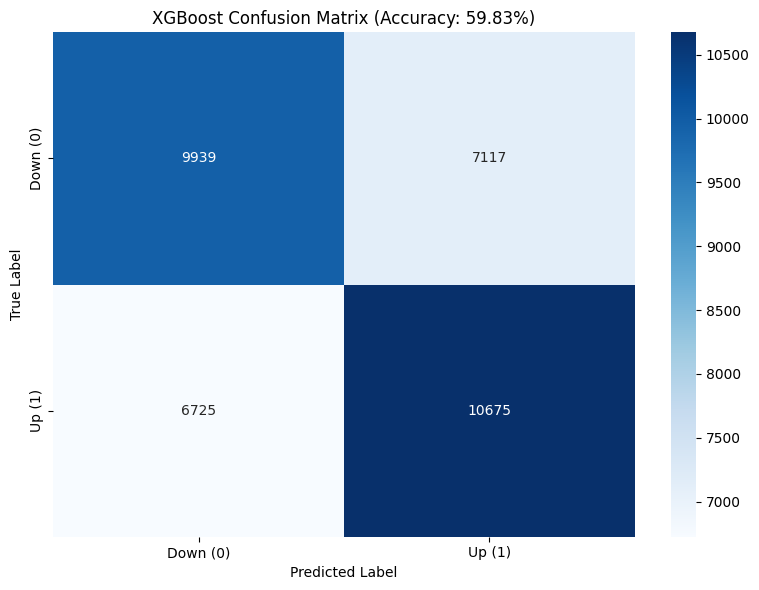


✓ Confusion matrix plotted


In [9]:
# Confusion matrix
cm = confusion_matrix(y_test_cpu, y_pred_cpu)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)'],
            yticklabels=['Down (0)', 'Up (1)'])
plt.title(f'XGBoost Confusion Matrix (Accuracy: {accuracy:.2%})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n✓ Confusion matrix plotted")

## 9. Save Model & Scaler

In [10]:
print("SAVING MODELS")
print("="*70)

# Create output directory
output_dir = Path(MODELS_DIR) / "baseline"
output_dir.mkdir(parents=True, exist_ok=True)

# Save XGBoost model
xgb_path = output_dir / "xgboost_baseline.json"
xgb_model.save_model(str(xgb_path))
print(f"✓ Saved XGBoost: {xgb_path}")

# Save scaler
scaler_path = output_dir / "scaler.pkl"
joblib.dump(scaler, str(scaler_path))
print(f"✓ Saved scaler: {scaler_path}")

# Save feature names
features_path = output_dir / "features.txt"
with open(features_path, 'w') as f:
    for feat in feature_cols:
        f.write(f"{feat}\n")
print(f"✓ Saved features: {features_path}")

# Save metadata
metadata = {
    'model': 'XGBoost',
    'target': TARGET,
    'n_features': len(feature_cols),
    'train_samples': len(dtrain.get_label()),
    'test_samples': len(dtest.get_label()),
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'train_dates': f"{train_dates.min()} to {train_dates.max()}",
    'test_dates': f"{test_dates.min()} to {test_dates.max()}",
    'training_time_seconds': train_time,
    'best_iteration': xgb_model.best_iteration
}

import json
metadata_path = output_dir / "metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved metadata: {metadata_path}")

print(f"\n✅ All models saved to: {output_dir}")

SAVING MODELS
✓ Saved XGBoost: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline/xgboost_baseline.json
✓ Saved scaler: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline/scaler.pkl
✓ Saved features: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline/features.txt
✓ Saved metadata: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline/metadata.json

✅ All models saved to: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline


## 10. Training Curve Visualization

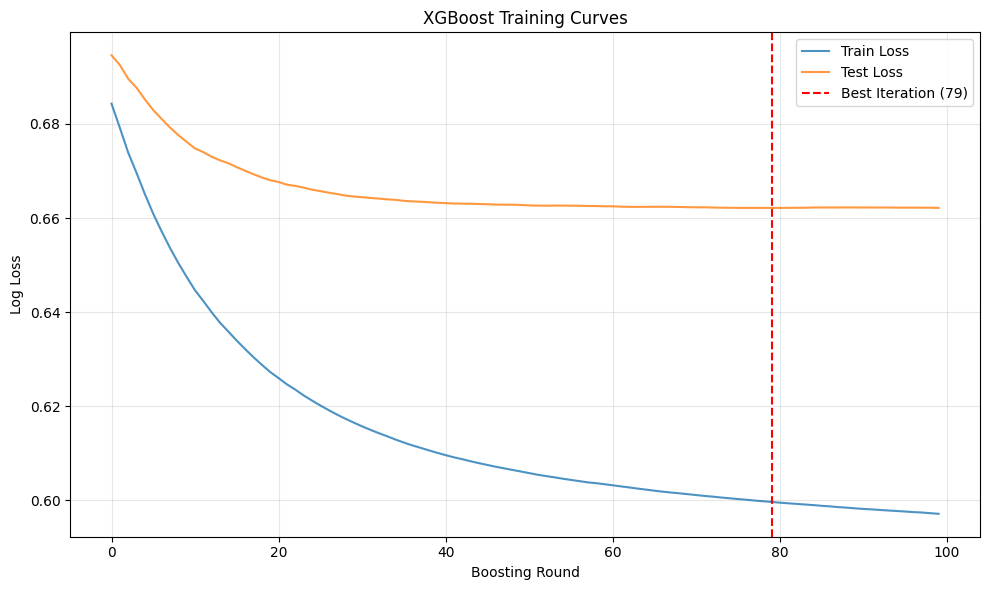

✓ Training curves plotted


In [11]:
# Plot training curves
train_loss = evals_result['train']['logloss']
test_loss = evals_result['test']['logloss']

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss', alpha=0.8)
plt.plot(test_loss, label='Test Loss', alpha=0.8)
plt.axvline(x=xgb_model.best_iteration, color='r', linestyle='--', 
            label=f'Best Iteration ({xgb_model.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Training curves plotted")

## Summary

**✅ Baseline Model Established**

**What we did:**
1. Loaded 16 days of engineered features (GPU)
2. Temporal train/test split (75%/25% by date)
3. GPU-accelerated feature scaling (cuML)
4. XGBoost training with GPU histogram method
5. Model evaluation and comparison to benchmarks

**Key Results:**
- Model: XGBoost (GPU-accelerated)
- Target: 10-second price direction
- Performance: See evaluation metrics above
- Saved to: `models/baseline/`

**GPU Optimization:**
- All data processing on GPU (cuDF)
- XGBoost with `tree_method='gpu_hist'`
- Batch loading to prevent OOM
- Aggressive memory cleanup

**Next Steps:**
- **05__feature_importance.ipynb**: SHAP analysis (identify top features)
- **06__walk_forward_validation.ipynb**: Temporal cross-validation
- **07__regime_ensemble.ipynb**: Volatility-based model segmentation (optional)
- **08__backtesting.ipynb**: Transaction costs and realistic P&L

**Academic Context:**
Our performance should be evaluated against:
- Random baseline: 50%
- Ntakaris benchmark: 54.2%
- Zhang benchmark: 57.6%

Any accuracy >52% indicates genuine predictive power for HFT crypto markets.